In [1]:
import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Download latest version
path = kagglehub.dataset_download("ayushmanyashaswi/loan-dataset-easy-to-understand-yashaswi")

print("Path to dataset files:", path)

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\ayushmanyashaswi\loan-dataset-easy-to-understand-yashaswi\versions\1


In [2]:
file = os.listdir(path)
file

['loan.csv']

In [3]:
df = pd.read_csv(path + "/loan.csv")
df.sample(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
101,LP001349,Male,No,0,Graduate,No,4843,3806.0,151.0,360.0,1.0,Semiurban,Y
145,LP001514,Female,Yes,0,Graduate,No,2330,4486.0,100.0,360.0,1.0,Semiurban,Y
402,LP002297,Male,No,0,Graduate,No,2500,20000.0,103.0,360.0,1.0,Semiurban,Y
114,LP001398,Male,No,0,Graduate,NaN,5050,0.0,118.0,360.0,1.0,Semiurban,Y
613,LP002990,Female,No,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,N
597,LP002943,Male,No,NaN,Graduate,No,2987,0.0,88.0,360.0,0.0,Semiurban,N
15,LP001032,Male,No,0,Graduate,No,4950,0.0,125.0,360.0,1.0,Urban,Y
72,LP001248,Male,No,0,Graduate,No,3500,0.0,81.0,300.0,1.0,Semiurban,Y
204,LP001691,Male,Yes,2,Not Graduate,No,3917,0.0,124.0,360.0,1.0,Semiurban,Y
457,LP002467,Male,Yes,0,Graduate,No,3708,2569.0,173.0,360.0,1.0,Urban,N


In [4]:
df.values

array([['LP001002', 'Male', 'No', ..., 1.0, 'Urban', 'Y'],
       ['LP001003', 'Male', 'Yes', ..., 1.0, 'Rural', 'N'],
       ['LP001005', 'Male', 'Yes', ..., 1.0, 'Urban', 'Y'],
       ...,
       ['LP002983', 'Male', 'Yes', ..., 1.0, 'Urban', 'Y'],
       ['LP002984', 'Male', 'Yes', ..., 1.0, 'Urban', 'Y'],
       ['LP002990', 'Female', 'No', ..., 0.0, 'Semiurban', 'N']],
      shape=(614, 13), dtype=object)

In [5]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
(df.isnull().sum()/df.shape[0])*100

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64

In [8]:
df['Dependents'].unique()

array(['0', '1', '2', '3+', nan], dtype=object)

In [9]:
for row in range(df.shape[0]):
    if df['Dependents'].iloc[row] == 'nan':
        pass
    elif df['Dependents'].iloc[row] == '3+':
        df['Dependents'].iloc[row] = 'HIGH'
    else:
        df['Dependents'].iloc[row] = 'LOW'
    

In [10]:
df[['Gender', 'Married', 'Dependents', 'Self_Employed', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']]

,Gender,Married,Dependents,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History
0,Male,No,LOW,No,NaN,360.0,1.0
1,Male,Yes,LOW,No,128.0,360.0,1.0
2,Male,Yes,LOW,Yes,66.0,360.0,1.0
3,Male,Yes,LOW,No,120.0,360.0,1.0
4,Male,No,LOW,No,141.0,360.0,1.0
...,...,...,...,...,...,...,...
609,Female,No,LOW,No,71.0,360.0,1.0
610,Male,Yes,HIGH,No,40.0,180.0,1.0
611,Male,Yes,LOW,No,253.0,360.0,1.0
612,Male,Yes,LOW,No,187.0,360.0,1.0


In [11]:
df['Dependents'].value_counts()

Dependents
LOW     563
HIGH     51
Name: count, dtype: int64

In [12]:
df.head(1)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,LOW,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y


In [13]:
# from sklearn.compose import ColumnTransformer
# from sklearn.impute import SimpleImputer

# tf1 = ColumnTransformer([
#         ('imputation_gender_married_Self_employed', SimpleImputer(strategy = 'most_frequent'), ['Gender', 'Married', 'Self_Employed'], 
#         ('imputation_loan_amount_term_credit_history'), SimpleImputer(), ['LoanAmount', 'Loan_Amount_Term', 'Credit_history'])

# ], remainder = 'passthrough')

In [14]:
# tf1.fit_transform(df)

In [15]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,LOW,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,LOW,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,LOW,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,LOW,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,LOW,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [16]:
# Categorical
df['Gender'].fillna(df['Gender'].value_counts().index[0], inplace = True)
df['Dependents'].fillna(df['Dependents'].value_counts().index[0], inplace = True)
df['Married'].fillna(df['Married'].value_counts().index[0], inplace = True)
df['Self_Employed'].fillna(df['Self_Employed'].value_counts().index[0], inplace = True)

# Numerical
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace = True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median(), inplace = True)
df['Credit_History'].fillna(df['Credit_History'].value_counts().index[0], inplace = True)

In [17]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [18]:
df.sample(20)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
242,LP001806,Male,No,LOW,Graduate,No,2965,5701.0,155.0,60.0,1.0,Urban,Y
25,LP001066,Male,Yes,LOW,Graduate,Yes,9560,0.0,191.0,360.0,1.0,Semiurban,Y
531,LP002720,Male,Yes,HIGH,Graduate,No,4281,0.0,100.0,360.0,1.0,Urban,Y
109,LP001384,Male,Yes,HIGH,Not Graduate,No,2071,754.0,94.0,480.0,1.0,Semiurban,Y
413,LP002332,Male,Yes,LOW,Not Graduate,No,2253,2033.0,110.0,360.0,1.0,Rural,Y
435,LP002393,Female,Yes,LOW,Graduate,No,10047,0.0,128.0,240.0,1.0,Semiurban,Y
507,LP002625,Male,No,LOW,Graduate,No,3583,0.0,96.0,360.0,1.0,Urban,N
0,LP001002,Male,No,LOW,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
372,LP002201,Male,Yes,LOW,Graduate,Yes,9323,7873.0,380.0,300.0,1.0,Rural,Y
508,LP002626,Male,Yes,LOW,Graduate,Yes,2479,3013.0,188.0,360.0,1.0,Urban,Y


In [23]:
df.drop(columns = ['Loan_ID	'], inplace = True)

KeyError: "['Loan_ID\\t'] not found in axis"

In [19]:
np.round(480/365, 1)

np.float64(1.3)

In [20]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [21]:
# unique values for each columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             614 non-null    object 
 2   Married            614 non-null    object 
 3   Dependents         614 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      614 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         614 non-null    float64
 9   Loan_Amount_Term   614 non-null    float64
 10  Credit_History     614 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


Gender : ['Male' 'Female']

Gender : Axes(0.125,0.11;0.775x0.77)


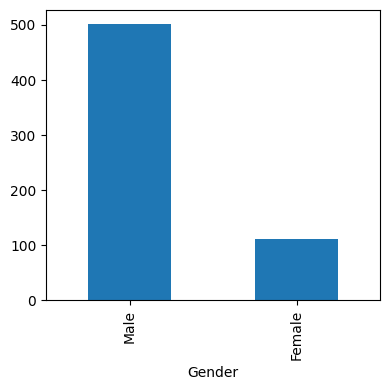

Married : ['No' 'Yes']

Married : Axes(0.125,0.11;0.775x0.77)


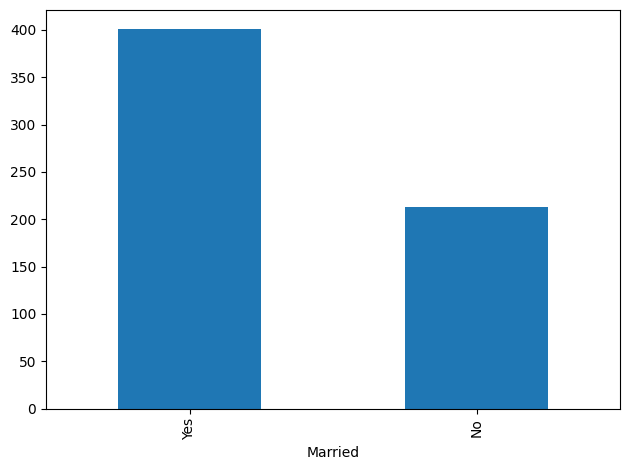

Dependents : ['LOW' 'HIGH']

Dependents : Axes(0.125,0.11;0.775x0.77)


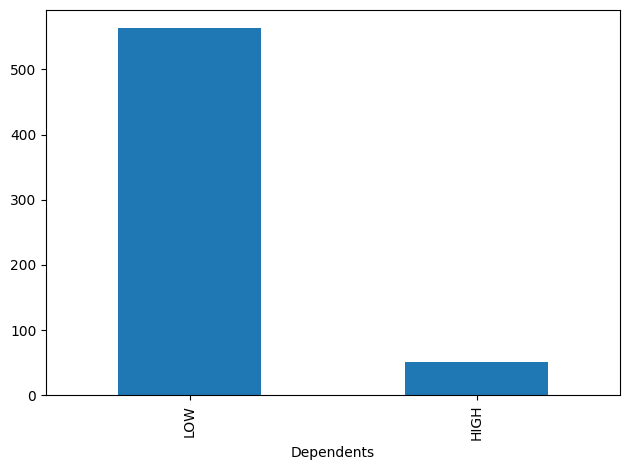

Education : ['Graduate' 'Not Graduate']

Education : Axes(0.125,0.11;0.775x0.77)


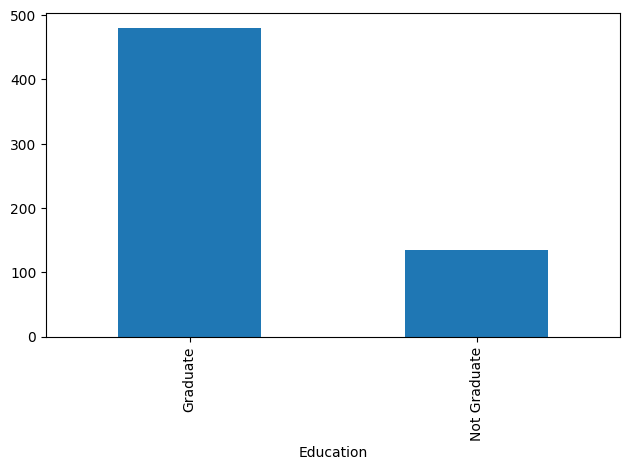

Self_Employed : ['No' 'Yes']

Self_Employed : Axes(0.125,0.11;0.775x0.77)


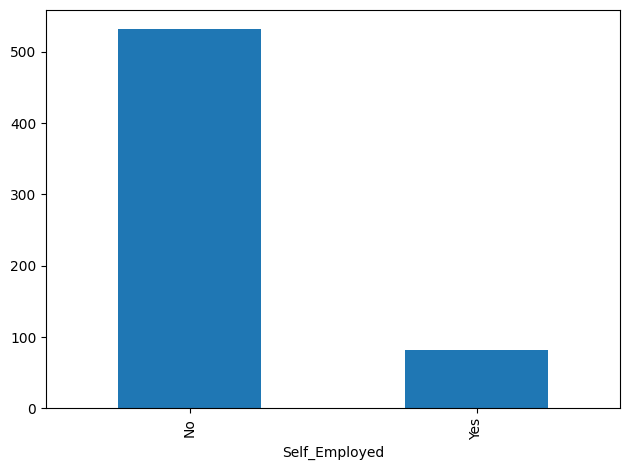

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

Property_Area : ['Urban' 'Rural' 'Semiurban']

Property_Area : Axes(0.125,0.11;0.775x0.77)


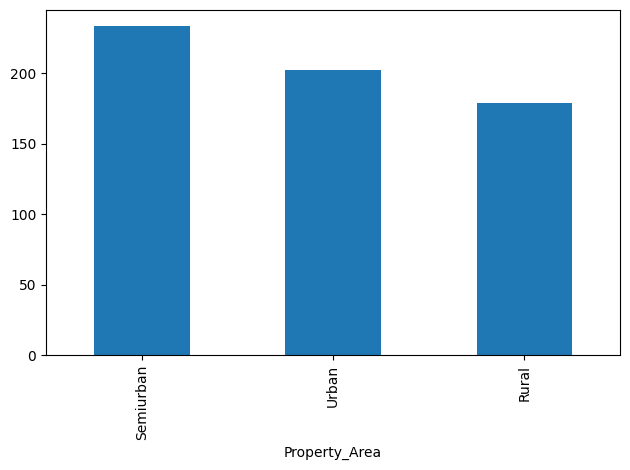

Loan_Status : ['Y' 'N']

Loan_Status : Axes(0.125,0.11;0.775x0.77)


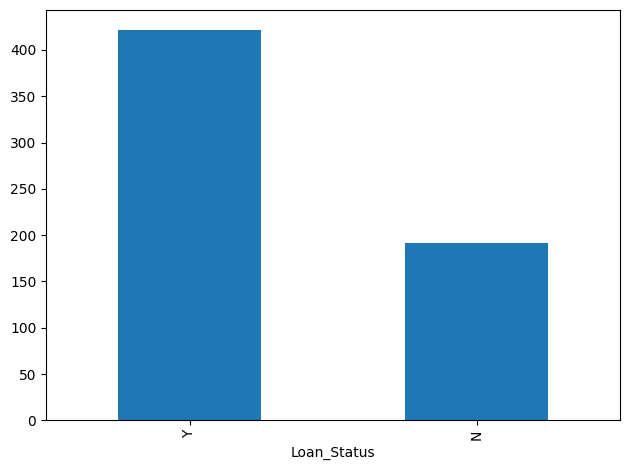

In [41]:
plt.figure(figsize = (4, 4))
for col in df.columns[1:]:
    if df[col].dtype == object:
        print(f"{col} : {df[col].unique()}")
        print()
        print(f"{col} : {df[col].value_counts().plot(kind = 'bar')}")
    plt.tight_layout()
    plt.show()

In [25]:
# EDA
df.sample(20)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
294,LP001947,Male,Yes,LOW,Graduate,No,2383,3334.000000,172.0,360.0,1.0,Semiurban,Y
324,LP002065,Male,Yes,HIGH,Graduate,No,15000,0.000000,300.0,360.0,1.0,Rural,Y
283,LP001917,Female,No,LOW,Graduate,No,1811,1666.000000,54.0,360.0,1.0,Urban,Y
421,LP002357,Female,No,LOW,Not Graduate,No,2720,0.000000,80.0,360.0,0.0,Urban,N
32,LP001097,Male,No,LOW,Graduate,Yes,4692,0.000000,106.0,360.0,1.0,Rural,N
428,LP002369,Male,Yes,LOW,Graduate,No,2920,16.120001,87.0,360.0,1.0,Rural,Y
24,LP001052,Male,Yes,LOW,Graduate,No,3717,2925.000000,151.0,360.0,1.0,Semiurban,N
391,LP002262,Male,Yes,HIGH,Graduate,No,9504,0.000000,275.0,360.0,1.0,Rural,Y
589,LP002926,Male,Yes,LOW,Graduate,Yes,2726,0.000000,106.0,360.0,0.0,Semiurban,N
161,LP001562,Male,Yes,LOW,Graduate,No,7933,0.000000,275.0,360.0,1.0,Urban,N


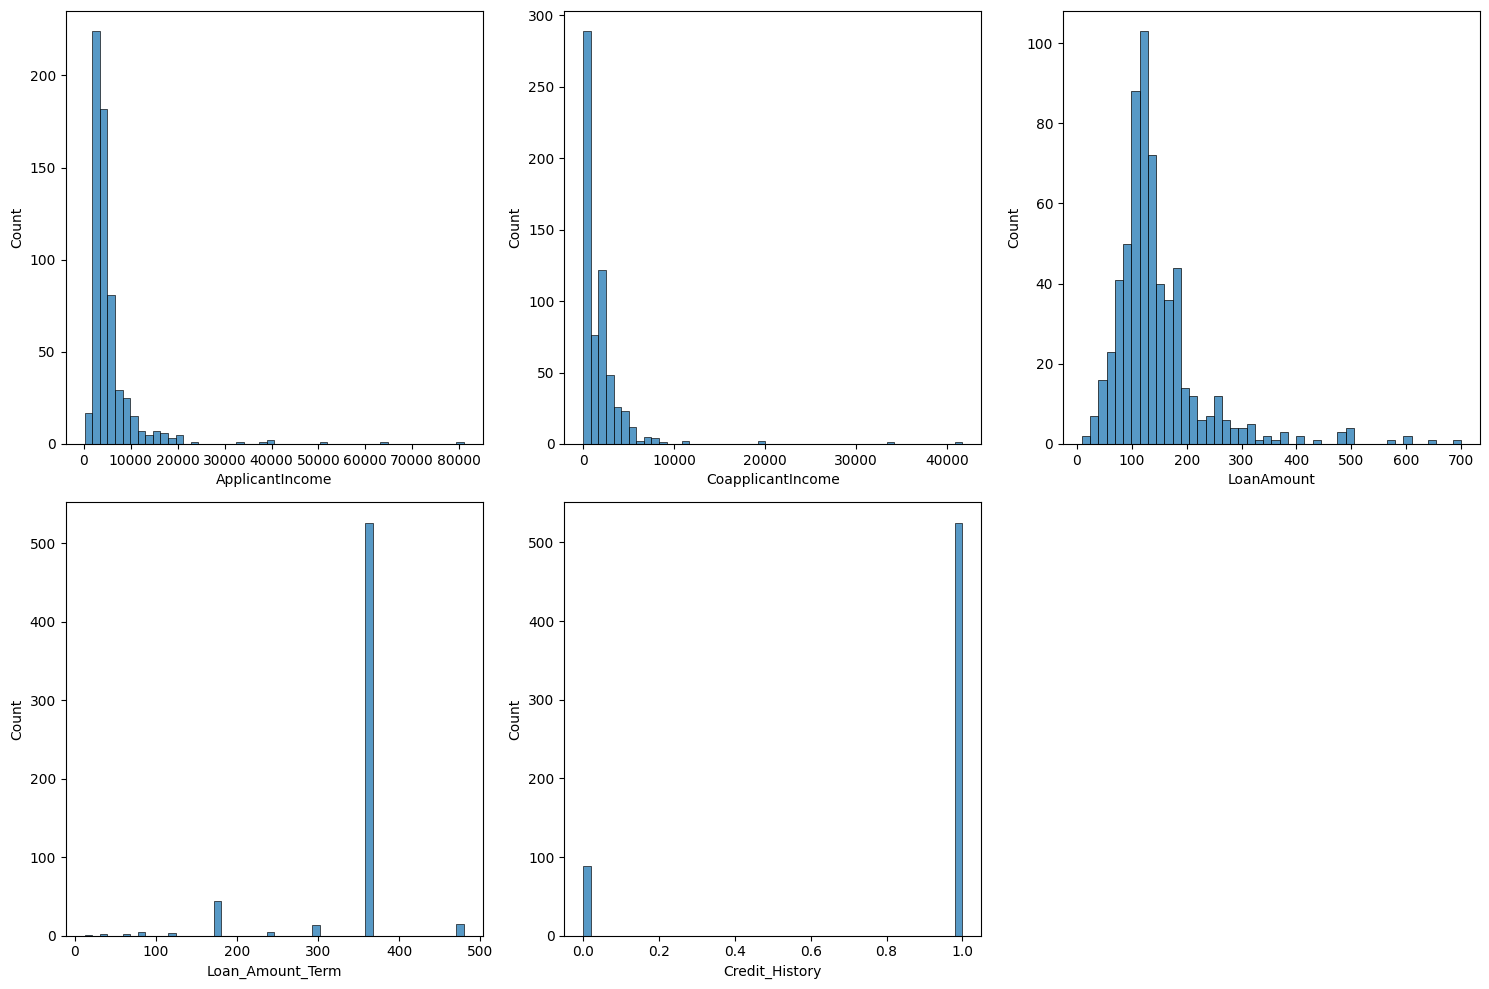

In [34]:
import seaborn as sns

plt.figure(figsize = (15, 10))
i = 1

numerical_col = []
for col in df.columns:
    if df[col].dtype != object:
        numerical_col.append(col)

for col in df.columns:
    if df[col].dtype != object:
        plt.subplot(2, 3, i)
        sns.histplot(df[col])
        i += 1
plt.tight_layout()
plt.show()

# Since my Data is following the right skewed nature  : 

In [36]:
df.sample(20)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
91,LP001318,Male,Yes,LOW,Graduate,No,6250,5654.0,188.0,180.0,1.0,Semiurban,Y
306,LP001993,Female,No,LOW,Graduate,No,3762,1666.0,135.0,360.0,1.0,Rural,Y
337,LP002112,Male,Yes,LOW,Graduate,Yes,2500,4600.0,176.0,360.0,1.0,Rural,Y
331,LP002098,Male,No,LOW,Graduate,No,2935,0.0,98.0,360.0,1.0,Semiurban,Y
186,LP001641,Male,Yes,LOW,Graduate,Yes,2178,0.0,66.0,300.0,0.0,Rural,N
204,LP001691,Male,Yes,LOW,Not Graduate,No,3917,0.0,124.0,360.0,1.0,Semiurban,Y
244,LP001811,Male,Yes,LOW,Not Graduate,No,3406,4417.0,123.0,360.0,1.0,Semiurban,Y
72,LP001248,Male,No,LOW,Graduate,No,3500,0.0,81.0,300.0,1.0,Semiurban,Y
229,LP001761,Male,No,LOW,Graduate,Yes,6400,0.0,200.0,360.0,1.0,Rural,Y
109,LP001384,Male,Yes,HIGH,Not Graduate,No,2071,754.0,94.0,480.0,1.0,Semiurban,Y


In [55]:
df.groupby(['Gender'	,'Married',	'Dependents'	,'Education'	,'Self_Employed'])['Loan_Status'].count()

Gender  Married  Dependents  Education     Self_Employed
Female  No       HIGH        Graduate      No                 2
                             Not Graduate  No                 1
                 LOW         Graduate      No                56
                                           Yes                8
                             Not Graduate  No                10
                                           Yes                3
        Yes      LOW         Graduate      No                23
                                           Yes                3
                             Not Graduate  No                 5
                                           Yes                1
Male    No       HIGH        Graduate      No                 2
                                           Yes                1
                             Not Graduate  No                 1
                 LOW         Graduate      No                87
                                           Yes 

In [56]:
df.sample(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
270,LP001888,Female,No,LOW,Graduate,No,3237,0.0,30.0,360.0,1.0,Urban,Y
60,LP001205,Male,Yes,LOW,Graduate,No,2500,3796.0,120.0,360.0,1.0,Urban,Y
525,LP002699,Male,Yes,LOW,Graduate,Yes,17500,0.0,400.0,360.0,1.0,Rural,Y
150,LP001528,Male,No,LOW,Graduate,No,6277,0.0,118.0,360.0,0.0,Rural,N
95,LP001326,Male,No,LOW,Graduate,No,6782,0.0,128.0,360.0,1.0,Urban,N
174,LP001603,Male,Yes,LOW,Not Graduate,Yes,4344,736.0,87.0,360.0,1.0,Semiurban,N
546,LP002768,Male,No,LOW,Not Graduate,No,3358,0.0,80.0,36.0,1.0,Semiurban,N
32,LP001097,Male,No,LOW,Graduate,Yes,4692,0.0,106.0,360.0,1.0,Rural,N
363,LP002178,Male,Yes,LOW,Graduate,No,3013,3033.0,95.0,300.0,1.0,Urban,Y
73,LP001250,Male,Yes,HIGH,Not Graduate,No,4755,0.0,95.0,360.0,0.0,Semiurban,N


In [59]:
df.groupby('Loan_Status')[['Gender'	,'Married',	'Dependents'	,'Education'	,'Self_Employed']].count()

,Gender,Married,Dependents,Education,Self_Employed
Loan_Status,,,,,
N,192,192,192,192,192
Y,422,422,422,422,422


In [64]:
# pd.crosstab(index = df['Loan_Status'], columns = [['Gender'	,'Married',	'Dependents'	,'Education'	,'Self_Employed']], aggfunc = 'sum')

In [67]:
df[df['Loan_Status'] == 'Y']['Gender'].value_counts()

Gender
Male      347
Female     75
Name: count, dtype: int64

In [73]:
df.groupby(['Loan_Status', 'Gender'])['Gender'].count()

Loan_Status  Gender
N            Female     37
             Male      155
Y            Female     75
             Male      347
Name: Gender, dtype: int64

In [77]:
df.groupby(['Loan_Status', 'Education', 'Gender'])[['Gender', 'Education']].count()

Gender  Education
Loan_Status Education    Gender                   
N           Graduate     Female      31         31
                         Male       109        109
            Not Graduate Female       6          6
                         Male        46         46
Y           Graduate     Female      61         61
                         Male       279        279
            Not Graduate Female      14         14
                         Male        68         68

In [90]:
pd.crosstab(index = df['Loan_Status'], columns = df['Gender'], values = df['Gender'] , aggfunc = 'count')

Gender,Female,Male
Loan_Status,,
N,37,155
Y,75,347


In [91]:
df.sample(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
515,LP002659,Male,Yes,HIGH,Graduate,No,3466,3428.0,150.0,360.0,1.0,Rural,Y
552,LP002785,Male,Yes,LOW,Graduate,No,3333,3250.0,158.0,360.0,1.0,Urban,Y
358,LP002158,Male,Yes,LOW,Not Graduate,No,3000,1666.0,100.0,480.0,0.0,Urban,N
112,LP001391,Male,Yes,LOW,Not Graduate,No,3572,4114.0,152.0,360.0,0.0,Rural,N
36,LP001109,Male,Yes,LOW,Graduate,No,1828,1330.0,100.0,360.0,0.0,Urban,N
343,LP002126,Male,Yes,HIGH,Not Graduate,No,3173,0.0,74.0,360.0,1.0,Semiurban,Y
368,LP002190,Male,Yes,LOW,Graduate,No,6325,0.0,175.0,360.0,1.0,Semiurban,Y
529,LP002716,Male,No,LOW,Not Graduate,No,6783,0.0,130.0,360.0,1.0,Semiurban,Y
88,LP001289,Male,No,LOW,Graduate,No,8566,0.0,210.0,360.0,1.0,Urban,Y
553,LP002788,Male,Yes,LOW,Not Graduate,No,2454,2333.0,181.0,360.0,0.0,Urban,N


In [92]:
df.drop(columns = ['Loan_ID'], inplace = True)

In [93]:
df.sample(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
27,Male,Yes,LOW,Not Graduate,No,4226,1040.0,110.0,360.0,1.0,Urban,Y
79,Male,Yes,HIGH,Not Graduate,Yes,3333,2166.0,130.0,360.0,1.0,Semiurban,Y
445,Male,Yes,LOW,Graduate,Yes,3466,1210.0,130.0,360.0,1.0,Rural,Y
527,Male,Yes,LOW,Not Graduate,No,5285,1430.0,161.0,360.0,0.0,Semiurban,Y
241,Male,Yes,LOW,Not Graduate,No,2510,1983.0,140.0,180.0,1.0,Urban,N
56,Male,Yes,LOW,Graduate,No,2132,1591.0,96.0,360.0,1.0,Semiurban,Y
383,Male,No,LOW,Graduate,Yes,7167,0.0,128.0,360.0,1.0,Urban,Y
417,Male,Yes,LOW,Graduate,Yes,1600,20000.0,239.0,360.0,1.0,Urban,N
309,Male,Yes,LOW,Not Graduate,No,7667,0.0,185.0,360.0,1.0,Rural,Y
460,Male,Yes,LOW,Graduate,Yes,2083,4083.0,160.0,360.0,1.0,Semiurban,Y


In [94]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.752443,342.410423,0.855049
std,6109.041673,2926.248369,84.107233,64.428629,0.352339
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,3812.500000,1188.500000,128.000000,360.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [95]:
150*1000

150000

In [96]:
81000*1000

81000000

In [101]:
df['Family_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

In [104]:
df.sample(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Family_Income
142,Male,No,LOW,Graduate,Yes,6950,0.0,175.0,180.0,1.0,Semiurban,Y,6950.0
258,Male,Yes,LOW,Graduate,No,14683,2100.0,304.0,360.0,1.0,Rural,N,16783.0
585,Male,Yes,LOW,Graduate,No,4283,3000.0,172.0,84.0,1.0,Rural,N,7283.0
231,Male,Yes,LOW,Graduate,No,3716,0.0,42.0,180.0,1.0,Rural,Y,3716.0
556,Female,No,LOW,Graduate,No,2667,1625.0,84.0,360.0,1.0,Urban,Y,4292.0
147,Male,Yes,LOW,Graduate,No,1538,1425.0,30.0,360.0,1.0,Urban,Y,2963.0
501,Female,No,LOW,Graduate,No,3159,0.0,100.0,360.0,1.0,Semiurban,Y,3159.0
298,Female,No,LOW,Graduate,No,5000,2541.0,151.0,480.0,1.0,Rural,N,7541.0
112,Male,Yes,LOW,Not Graduate,No,3572,4114.0,152.0,360.0,0.0,Rural,N,7686.0
532,Male,No,LOW,Graduate,No,3588,0.0,110.0,360.0,0.0,Rural,N,3588.0


In [105]:
df['Loan_Amount_Term'].unique()

array([360., 120., 240., 180.,  60., 300., 480.,  36.,  84.,  12.])

In [108]:
df['Loan_Amount_Term'].value_counts()

Loan_Amount_Term
360.0    526
180.0     44
480.0     15
300.0     13
84.0       4
240.0      4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [116]:
# for row in range(df.shape[0]):
    
#     if df['Loan_Amount_Term'].iloc[row] < 30:
#         df['Loan_Amount_Term'].iloc[row] = 1

#     elif  df['Loan_Amount_Term'].iloc[row] < 60:
#          df['Loan_Amount_Term'].iloc[row] = 2
        
#     elif  df['Loan_Amount_Term'].iloc[row] < 120:
#          df['Loan_Amount_Term'].iloc[row] = 3

#     elif  df['Loan_Amount_Term'].iloc[row] < 180:
#           df['Loan_Amount_Term'].iloc[row] = 4


In [117]:
df.sample(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Family_Income
304,Male,No,LOW,Graduate,No,4000,2500.0,140.0,360.0,1.0,Rural,Y,6500.0
233,Female,No,LOW,Graduate,No,8333,0.0,280.0,360.0,1.0,Semiurban,Y,8333.0
5,Male,Yes,LOW,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y,9613.0
438,Male,No,LOW,Graduate,Yes,10416,0.0,187.0,360.0,0.0,Urban,N,10416.0
137,Male,Yes,LOW,Graduate,Yes,3316,3500.0,88.0,360.0,1.0,Urban,Y,6816.0
286,Female,No,LOW,Graduate,Yes,2600,1717.0,99.0,300.0,1.0,Semiurban,N,4317.0
90,Male,Yes,LOW,Graduate,No,2958,2900.0,131.0,360.0,1.0,Semiurban,Y,5858.0
309,Male,Yes,LOW,Not Graduate,No,7667,0.0,185.0,360.0,1.0,Rural,Y,7667.0
513,Male,Yes,LOW,Graduate,No,2130,6666.0,70.0,180.0,1.0,Semiurban,N,8796.0
104,Male,Yes,LOW,Graduate,No,3816,754.0,160.0,360.0,1.0,Urban,Y,4570.0


In [118]:
df.drop(columns = ['ApplicantIncome', 'CoapplicantIncome'], inplace = True)

In [119]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Family_Income
0,Male,No,LOW,Graduate,No,128.0,360.0,1.0,Urban,Y,5849.0
1,Male,Yes,LOW,Graduate,No,128.0,360.0,1.0,Rural,N,6091.0
2,Male,Yes,LOW,Graduate,Yes,66.0,360.0,1.0,Urban,Y,3000.0
3,Male,Yes,LOW,Not Graduate,No,120.0,360.0,1.0,Urban,Y,4941.0
4,Male,No,LOW,Graduate,No,141.0,360.0,1.0,Urban,Y,6000.0


In [122]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [123]:
x_train, x_test, y_train, y_test = train_test_split(df.drop(columns = ['Loan_Status']), df['Loan_Status'], test_size = 0.2, random_state=34)

In [125]:
x_train.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Family_Income'],
      dtype='object')

In [126]:
t1 = ColumnTransformer([
    ('encode_gender_married_dependents_education_self_employed_property_area', 
     OneHotEncoder(sparse_output = False, drop = 'first', handle_unknown = 'ignore'), [0, 1, 2, 3, 4,8])
], remainder = 'passthrough')

In [128]:
boost_pipe = Pipeline([
    ('t1', t1),
    ('scale', StandardScaler()),
    ('Boosting_model', GradientBoostingClassifier())
])

In [129]:
boost_pipe.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('t1', ...), ('scale', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encode_gender_married_..._employed_property_area', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

In [130]:
random_pipe = Pipeline([
    ('t1', t1),
    ('scale', StandardScaler()),
    ('Boosting_model', RandomForestClassifier())
])

bag_pipe = Pipeline([
    ('t1', t1),
    ('scale', StandardScaler()),
    ('Boosting_model', BaggingClassifier())
])

svm_pipe = Pipeline([
    ('t1', t1),
    ('scale', StandardScaler()),
    ('Boosting_model', SVC())
])

log_pipe = Pipeline([
    ('t1', t1),
    ('scale', StandardScaler()),
    ('Boosting_model', LogisticRegression())
])

In [ ]:
pipelines = [('boosting', boost_pipe,) random_pipe, bag_pipe, svm_pipe, log_pipe]
for pipe in pipelines:
    pipe.fit(x_train, y_train)

In [132]:
pipelines

[Pipeline(steps=[('t1',
                  ColumnTransformer(remainder='passthrough',
                                    transformers=[('encode_gender_married_dependents_education_self_employed_property_area',
                                                   OneHotEncoder(drop='first',
                                                                 handle_unknown='ignore',
                                                                 sparse_output=False),
                                                   [0, 1, 2, 3, 4, 8])])),
                 ('scale', StandardScaler()),
                 ('Boosting_model', GradientBoostingClassifier())]),
 Pipeline(steps=[('t1',
                  ColumnTransformer(remainder='passthrough',
                                    transformers=[('encode_gender_married_dependents_education_self_employed_property_area',
                                                   OneHotEncoder(drop='first',
                                                       

In [133]:
bag_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('t1', ...), ('scale', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encode_gender_married_..._employed_property_area', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

In [134]:
boost_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('t1', ...), ('scale', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encode_gender_married_..._employed_property_area', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

In [135]:
log_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('t1', ...), ('scale', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encode_gender_married_..._employed_property_area', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

In [138]:
from sklearn.metrics import accuracy_score

for pipe in pipelines:
    print(f"Accuracy Score: {accuracy_score(y_test, pipe.predict(x_test))}")
    print()

Accuracy Score: 0.7804878048780488

Accuracy Score: 0.7317073170731707

Accuracy Score: 0.7479674796747967

Accuracy Score: 0.7886178861788617

Accuracy Score: 0.7804878048780488



In [140]:
svm_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('t1', ...), ('scale', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encode_gender_married_..._employed_property_area', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output

In [144]:
import pickle

with open('svm.pkl', 'wb') as f:
    pickle.dump(svm_pipe, f)

In [145]:
x_train.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area',
       'Family_Income'],
      dtype='object')

In [3]:
import pickle
with open(r'C:\Users\Admin\OneDrive\Desktop\ML_projects\loan_approval_system\svm.pkl', 'rb') as file:
    pipe = pickle.load(file)

In [5]:
pipe.predict([['Male',	'No',	'LOW',	'Graduate',	'No'	,128.0,	360.0,	1.0,	'Urban'	,5849.0]])[0]

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


'Y'